# Phase 8 — Statistical Validation

Four-block validation framework:
- **Block A** — Information Coefficient (IC) deep-dive
- **Block B** — Bootstrap 95% confidence intervals
- **Block C** — Monte Carlo permutation (temporal + cross-sectional)
- **Block D** — Reality check (random trade removal)

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

from src.data import load_prices, compute_returns, load_risk_free_rate
from src.signals import load_signals
from src.backtest import load_backtest_returns
from src.hypothesis_tests import compute_me_forward_returns
from src.stats_validation import (
    ic_full_analysis, bootstrap_ci, monte_carlo_permutation, reality_check
)

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.titlesize': 11,
                     'axes.labelsize': 10, 'axes.spines.top': False, 'axes.spines.right': False})
print('Libraries loaded.')

Libraries loaded.


In [2]:
prices  = load_prices(directory='../data/processed')
returns = compute_returns(prices)
signals = load_signals(directory='../data/processed')

rf_daily   = load_risk_free_rate(directory='../data/processed')
rf_monthly = (1 + rf_daily).resample('ME').prod() - 1

bt_rets  = load_backtest_returns(directory='../data/processed')
hrp_ret  = bt_rets['D: HRP'].dropna()
spy_ret  = prices.resample('ME').last()['SPY'].pct_change().dropna()
fwd      = compute_me_forward_returns(prices)

print(f'Strategy: {len(hrp_ret)} months  ({hrp_ret.index[0].date()} – {hrp_ret.index[-1].date()})')

Strategy: 258 months  (2005-01-31 – 2026-06-30)


## Block A — Information Coefficient

Spearman rank correlation between composite momentum score and next-month return.

In [3]:
ic_res = ic_full_analysis(signals, fwd)


───────────────────────────────────────────────────────
Block A — Information Coefficient
───────────────────────────────────────────────────────
  N obs            : 245
  Mean IC          : 0.07231
  IC Std           : 0.40929
  ICIR (monthly)   : 0.1767
  ICIR (annual)    : 0.6120
  t-stat           : 2.7654
  p-value          : 0.006121  ***
  IC > 0           : 55.1%
  95% CI (boot)    : [0.02150, 0.12345]
  Jarque-Bera p    : 0.0140  (non-normal)
  Shapiro-Wilk p   : 0.0012
  Autocorr (lag-1) : 0.0127  (negligible)

  Annual IC (mean per year):
    2006: +0.1396  ████████
    2007: +0.0691  ████
    2008: +0.1397  ████████
    2009: +0.0244  █
    2010: +0.1555  █████████
    2011: +0.0652  ███
    2012: -0.0333  ██
    2013: +0.2199  █████████████
    2014: +0.1976  ███████████
    2015: +0.1741  ██████████
    2016: -0.2012  ████████████
    2017: +0.2229  █████████████
    2018: -0.0664  ███
    2019: -0.0226  █
    2020: +0.0988  █████
    2021: +0.0994  █████
    2022: +0.0

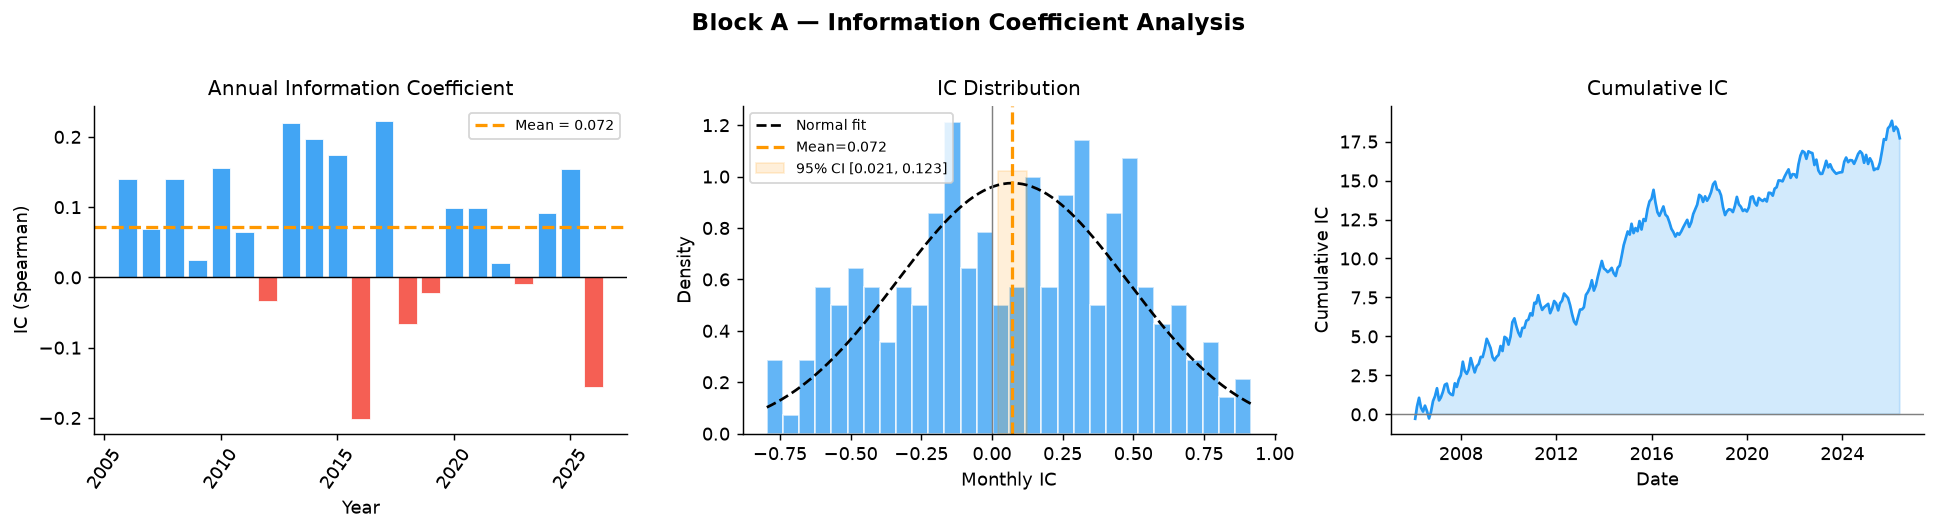

Mean IC=0.0723, ICIR(ann)=0.6120, t=2.765, p=0.0061


In [4]:
ic_series = ic_res['ic_series']
annual_ic = ic_res['annual_ic']
ci_lo     = ic_res['boot_mean_ic_lo']
ci_hi     = ic_res['boot_mean_ic_hi']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Annual IC bars
ax = axes[0]
years = annual_ic.index.tolist()
vals  = annual_ic.values.tolist()
cols  = ['#2196F3' if v >= 0 else '#F44336' for v in vals]
ax.bar(years, vals, color=cols, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(ic_res['mean_ic'], color='#FF9800', linewidth=1.8, linestyle='--',
           label=f"Mean = {ic_res['mean_ic']:.3f}")
ax.set_title('Annual Information Coefficient')
ax.set_xlabel('Year')
ax.set_ylabel('IC (Spearman)')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=55)

# IC distribution
ax = axes[1]
mu_ic, sd_ic = ic_series.mean(), ic_series.std()
ax.hist(ic_series.dropna(), bins=30, color='#2196F3', alpha=0.7, edgecolor='white', density=True)
x_r = np.linspace(ic_series.min(), ic_series.max(), 200)
ax.plot(x_r, norm.pdf(x_r, mu_ic, sd_ic), 'k--', linewidth=1.5, label='Normal fit')
ax.axvline(0, color='gray', linewidth=0.8)
ax.axvline(mu_ic, color='#FF9800', linewidth=1.8, linestyle='--', label=f'Mean={mu_ic:.3f}')
peak = norm.pdf(mu_ic, mu_ic, sd_ic)
ax.fill_betweenx([0, peak * 1.05], ci_lo, ci_hi, alpha=0.15, color='#FF9800',
                 label=f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}]')
ax.set_title('IC Distribution')
ax.set_xlabel('Monthly IC')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# Cumulative IC
ax = axes[2]
cum_ic = ic_series.dropna().cumsum()
ax.plot(cum_ic.index, cum_ic.values, color='#2196F3', linewidth=1.5)
ax.axhline(0, color='gray', linewidth=0.8)
ax.fill_between(cum_ic.index, cum_ic.values, 0, where=(cum_ic.values > 0), alpha=0.2, color='#2196F3')
ax.fill_between(cum_ic.index, cum_ic.values, 0, where=(cum_ic.values <= 0), alpha=0.2, color='#F44336')
ax.set_title('Cumulative IC')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative IC')

fig.suptitle('Block A — Information Coefficient Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f"Mean IC={ic_res['mean_ic']:.4f}, ICIR(ann)={ic_res['icir_annual']:.4f}, t={ic_res['t_stat']:.3f}, p={ic_res['p_value']:.4f}")

## Block B — Bootstrap Confidence Intervals

10,000 bootstrap resamples → uncertainty estimates for Sharpe, CAGR, MaxDD, Sortino.

In [5]:
boot_res = bootstrap_ci(hrp_ret, rf_monthly)


───────────────────────────────────────────────────────
Block B — Bootstrap  (10,000 samples, 95% CI)
───────────────────────────────────────────────────────
  Metric         Observed  Mean boot                 95% CI     P>0
  ──────────── ────────── ────────── ──────────────────────  ──────
  Sharpe           0.9088     0.9168   [  0.4930,   1.3410]   1.000
  CAGR             0.1095     0.1158   [  0.0697,   0.1636]   1.000
  MaxDD           -0.1286    -0.1673   [ -0.2805,  -0.0958]   0.000
  Sortino          1.3336     1.3725   [  0.6809,   2.1896]   1.000


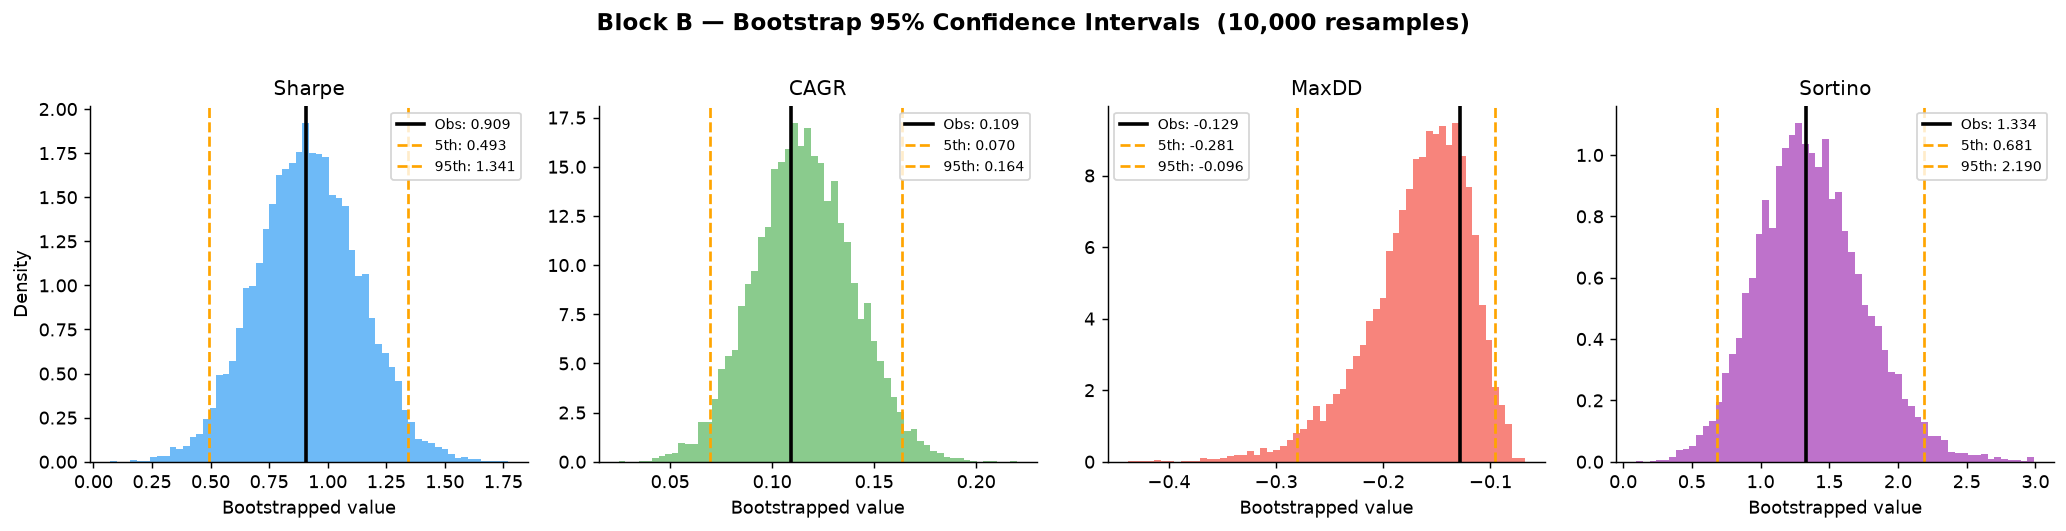

In [6]:
metrics   = ['Sharpe', 'CAGR', 'MaxDD', 'Sortino']
obs_vals  = [boot_res['observed'][k] for k in ['sharpe', 'cagr', 'maxdd', 'sortino']]
ci_keys   = ['ci_sharpe', 'ci_cagr', 'ci_maxdd', 'ci_sortino']
dist_keys = ['sharpe', 'cagr', 'maxdd', 'sortino']
colors_b  = ['#2196F3', '#4CAF50', '#F44336', '#9C27B0']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, m, obs, ck, dk, c in zip(axes, metrics, obs_vals, ci_keys, dist_keys, colors_b):
    ci   = boot_res[ck]
    dist = boot_res['dist'][dk]
    lo, hi = ci['lo95'], ci['hi95']
    ax.hist(dist, bins=60, color=c, alpha=0.65, edgecolor='none', density=True)
    ax.axvline(obs, color='black',  linewidth=2,   label=f'Obs: {obs:.3f}')
    ax.axvline(lo,  color='orange', linewidth=1.5, linestyle='--', label=f'5th: {lo:.3f}')
    ax.axvline(hi,  color='orange', linewidth=1.5, linestyle='--', label=f'95th: {hi:.3f}')
    ax.set_title(m)
    ax.set_xlabel('Bootstrapped value')
    ax.legend(fontsize=7.5)

axes[0].set_ylabel('Density')
fig.suptitle('Block B — Bootstrap 95% Confidence Intervals  (10,000 resamples)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Block C — Monte Carlo Permutation

- **C1 (Temporal)**: Shuffle return order → MaxDD distribution. Tests if low drawdown is due to lucky timing.
- **C2 (Cross-sectional)**: Randomly select N assets from eligible pool at each month → Sharpe distribution. Tests if momentum score adds genuine selection skill.

In [7]:
mc_res = monte_carlo_permutation(
    hrp_ret, signals=signals, fwd_returns=fwd,
    rf_monthly=rf_monthly, spy_returns=spy_ret,
)


────────────────────────────────────────────────────────────
Block C — Monte Carlo  (10,000 sims each)
────────────────────────────────────────────────────────────
  C1 — Temporal permutation (MaxDD test):
    Observed MaxDD           : -12.86%
    Mean random MaxDD        : -16.60%
    P(random MaxDD ≥ observed): 0.1549  (timing may contribute)

  C2 — Cross-sectional permutation (signal skill test):
    Observed Sharpe (EW top-N)  : 0.5874
    Mean random Sharpe          : 0.4633
    Std random Sharpe           : 0.0934
    Empirical p-value           : 0.094000  *
    Percentile rank             : 90.60th percentile
    SPY Sharpe                  : 0.6593
    P(random ≥ SPY Sharpe)      : 0.0195


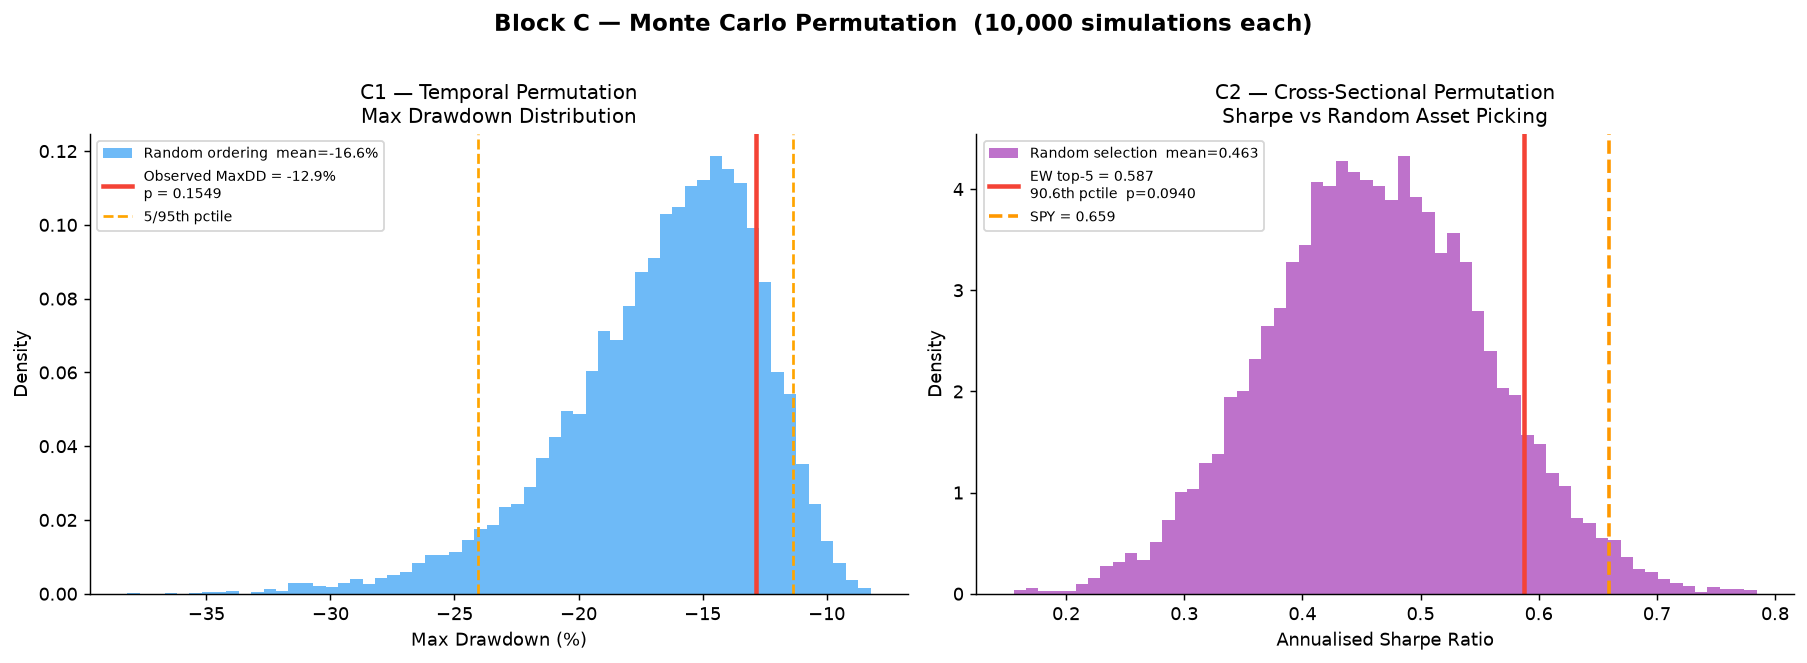

C1: P(random MaxDD >= observed) = 0.1549
C2: EW top-N at 90.6th percentile, p = 0.0940


In [8]:
c1 = mc_res['c1_temporal']
c2 = mc_res['c2_crosssectional']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# C1: MaxDD distribution
ax = axes[0]
perm_mdd_pct = c1['perm_maxdd'] * 100
obs_mdd_pct  = c1['observed_maxdd'] * 100
ax.hist(perm_mdd_pct, bins=60, color='#2196F3', alpha=0.65, edgecolor='none', density=True,
        label=f'Random ordering  mean={perm_mdd_pct.mean():.1f}%')
ax.axvline(obs_mdd_pct, color='#F44336', linewidth=2.5,
           label=f'Observed MaxDD = {obs_mdd_pct:.1f}%\np = {c1["p_value"]:.4f}')
ax.axvline(np.percentile(perm_mdd_pct, 5),  color='orange', linewidth=1.5, linestyle='--', label='5/95th pctile')
ax.axvline(np.percentile(perm_mdd_pct, 95), color='orange', linewidth=1.5, linestyle='--')
ax.set_title('C1 — Temporal Permutation\nMax Drawdown Distribution')
ax.set_xlabel('Max Drawdown (%)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# C2: Random Sharpe distribution
ax = axes[1]
rand_sh  = c2['rand_sharpes']
obs_sh   = c2['observed_sharpe_ew']
bench_sh = c2['benchmark_sharpe']
valid_sh = rand_sh[~np.isnan(rand_sh)]
ax.hist(valid_sh, bins=60, color='#9C27B0', alpha=0.65, edgecolor='none', density=True,
        label=f'Random selection  mean={np.nanmean(rand_sh):.3f}')
ax.axvline(obs_sh, color='#F44336', linewidth=2.5,
           label=f'EW top-5 = {obs_sh:.3f}\n{c2["percentile_rank"]*100:.1f}th pctile  p={c2["p_value"]:.4f}')
if bench_sh is not None:
    ax.axvline(bench_sh, color='#FF9800', linewidth=2, linestyle='--', label=f'SPY = {bench_sh:.3f}')
ax.set_title('C2 — Cross-Sectional Permutation\nSharpe vs Random Asset Picking')
ax.set_xlabel('Annualised Sharpe Ratio')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

fig.suptitle('Block C — Monte Carlo Permutation  (10,000 simulations each)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"C1: P(random MaxDD >= observed) = {c1['p_value']:.4f}")
print(f"C2: EW top-N at {c2['percentile_rank']*100:.1f}th percentile, p = {c2['p_value']:.4f}")

## Block D — Reality Check

Randomly replace 10/20/30% of monthly returns with the risk-free rate.  
**Question:** Does the strategy still outperform if we miss that fraction of trades?

In [9]:
rc_res = reality_check(hrp_ret, rf_monthly, spy_returns=spy_ret)


───────────────────────────────────────────────────────
Block D — Reality Check  (5,000 sims per rate)
───────────────────────────────────────────────────────
  Observed Sharpe   : 0.9088
  SPY Sharpe        : 0.6575

     Removal   Mean Sh   5th pct  95th pct     P>0    P>SPY  Still profitable
  ──────────  ────────  ────────  ────────  ──────  ───────  ────────────────


         10%     0.861     0.754     0.975   1.000    1.000             YES ✓
         20%     0.808     0.653     0.971   1.000    0.946             YES ✓


         30%     0.751     0.562     0.954   1.000    0.787             YES ✓


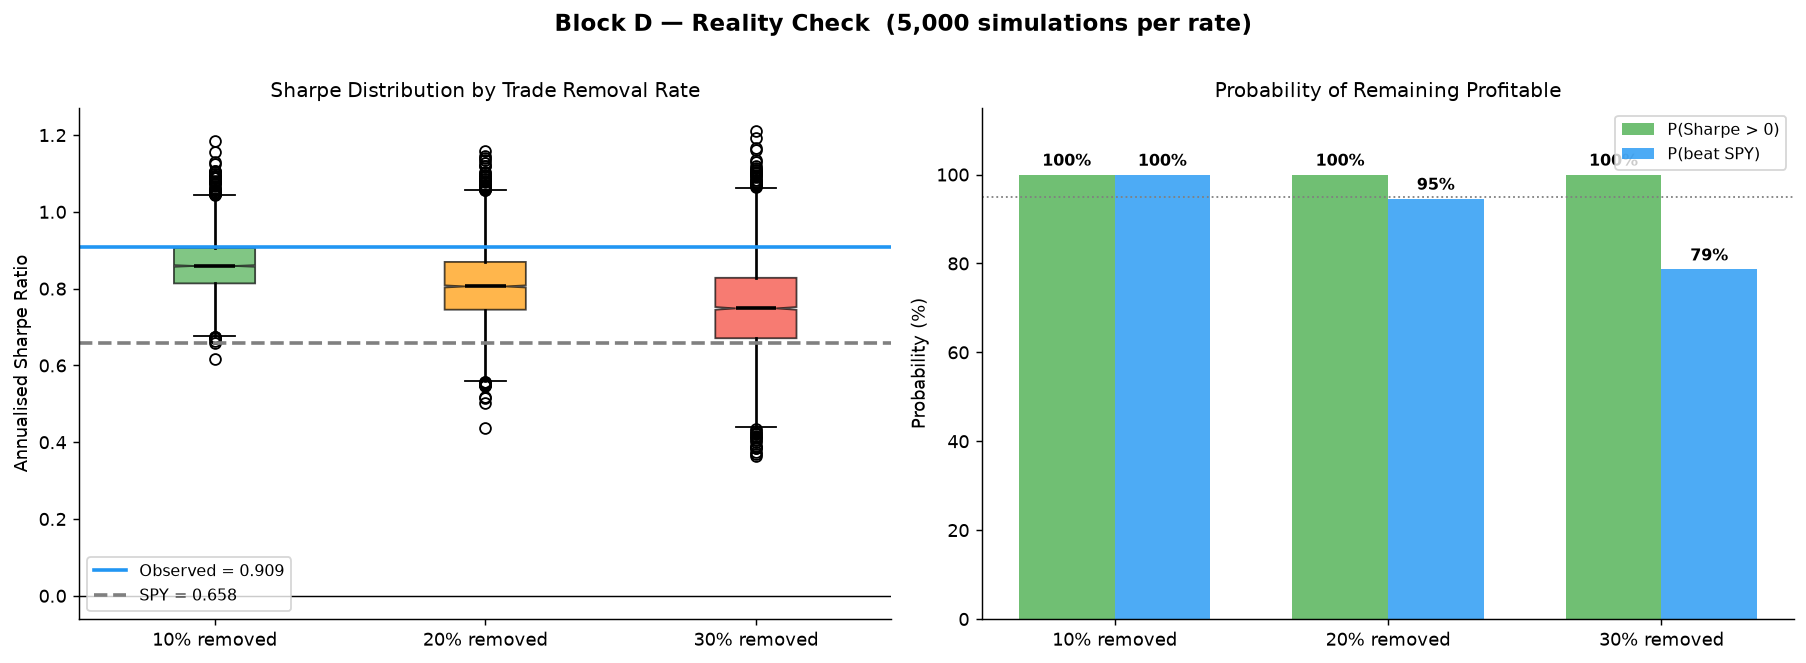


      Rate   Mean Sh   5th pct  95th pct     P>0    P>SPY
       10%     0.861     0.754     0.975   1.000    1.000
       20%     0.808     0.653     0.971   1.000    0.946
       30%     0.751     0.562     0.954   1.000    0.787


In [10]:
rates = [10, 20, 30]
obs_sh_rc = rc_res['observed_sharpe']
spy_sh_rc = rc_res['spy_sharpe']
dist_list = [rc_res['results'][f'{r}pct']['dist_sharpe'] for r in rates]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plots
ax = axes[0]
bp = ax.boxplot(dist_list, patch_artist=True, notch=True,
                medianprops={'color': 'black', 'linewidth': 2},
                whiskerprops={'linewidth': 1.5})
for patch, c in zip(bp['boxes'], ['#4CAF50', '#FF9800', '#F44336']):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.axhline(obs_sh_rc, color='#2196F3', linewidth=2, label=f'Observed = {obs_sh_rc:.3f}')
if spy_sh_rc:
    ax.axhline(spy_sh_rc, color='gray', linewidth=2, linestyle='--', label=f'SPY = {spy_sh_rc:.3f}')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['10% removed', '20% removed', '30% removed'])
ax.set_title('Sharpe Distribution by Trade Removal Rate')
ax.set_ylabel('Annualised Sharpe Ratio')
ax.legend(fontsize=9)

# Probability bars
ax = axes[1]
p_gt0 = [rc_res['results'][f'{r}pct']['p_gt0']     for r in rates]
p_spy  = [rc_res['results'][f'{r}pct']['p_beat_spy'] for r in rates]
x = np.arange(len(rates))
w = 0.35
ax.bar(x - w/2, [v*100 for v in p_gt0], w, color='#4CAF50', alpha=0.8, label='P(Sharpe > 0)')
ax.bar(x + w/2, [v*100 for v in p_spy],  w, color='#2196F3', alpha=0.8, label='P(beat SPY)')
ax.set_xticks(x)
ax.set_xticklabels([f'{r}% removed' for r in rates])
ax.set_ylim(0, 115)
ax.set_ylabel('Probability (%)')
ax.set_title('Probability of Remaining Profitable')
ax.legend(fontsize=9)
ax.axhline(95, color='gray', linewidth=1, linestyle=':')
for i, (g, s) in enumerate(zip(p_gt0, p_spy)):
    ax.text(i - w/2, g*100 + 2, f'{g*100:.0f}%', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + w/2, s*100 + 2, f'{s*100:.0f}%', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Block D — Reality Check  (5,000 simulations per rate)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\n  {'Rate':>8}  {'Mean Sh':>8}  {'5th pct':>8}  {'95th pct':>8}  {'P>0':>6}  {'P>SPY':>7}")
for r in rates:
    d = rc_res['results'][f'{r}pct']
    print(f"  {str(r)+'%':>8}  {d['mean_sh']:>8.3f}  {d['lo5']:>8.3f}  {d['hi95']:>8.3f}  {d['p_gt0']:>6.3f}  {d['p_beat_spy']:>7.3f}")

## Summary Dashboard

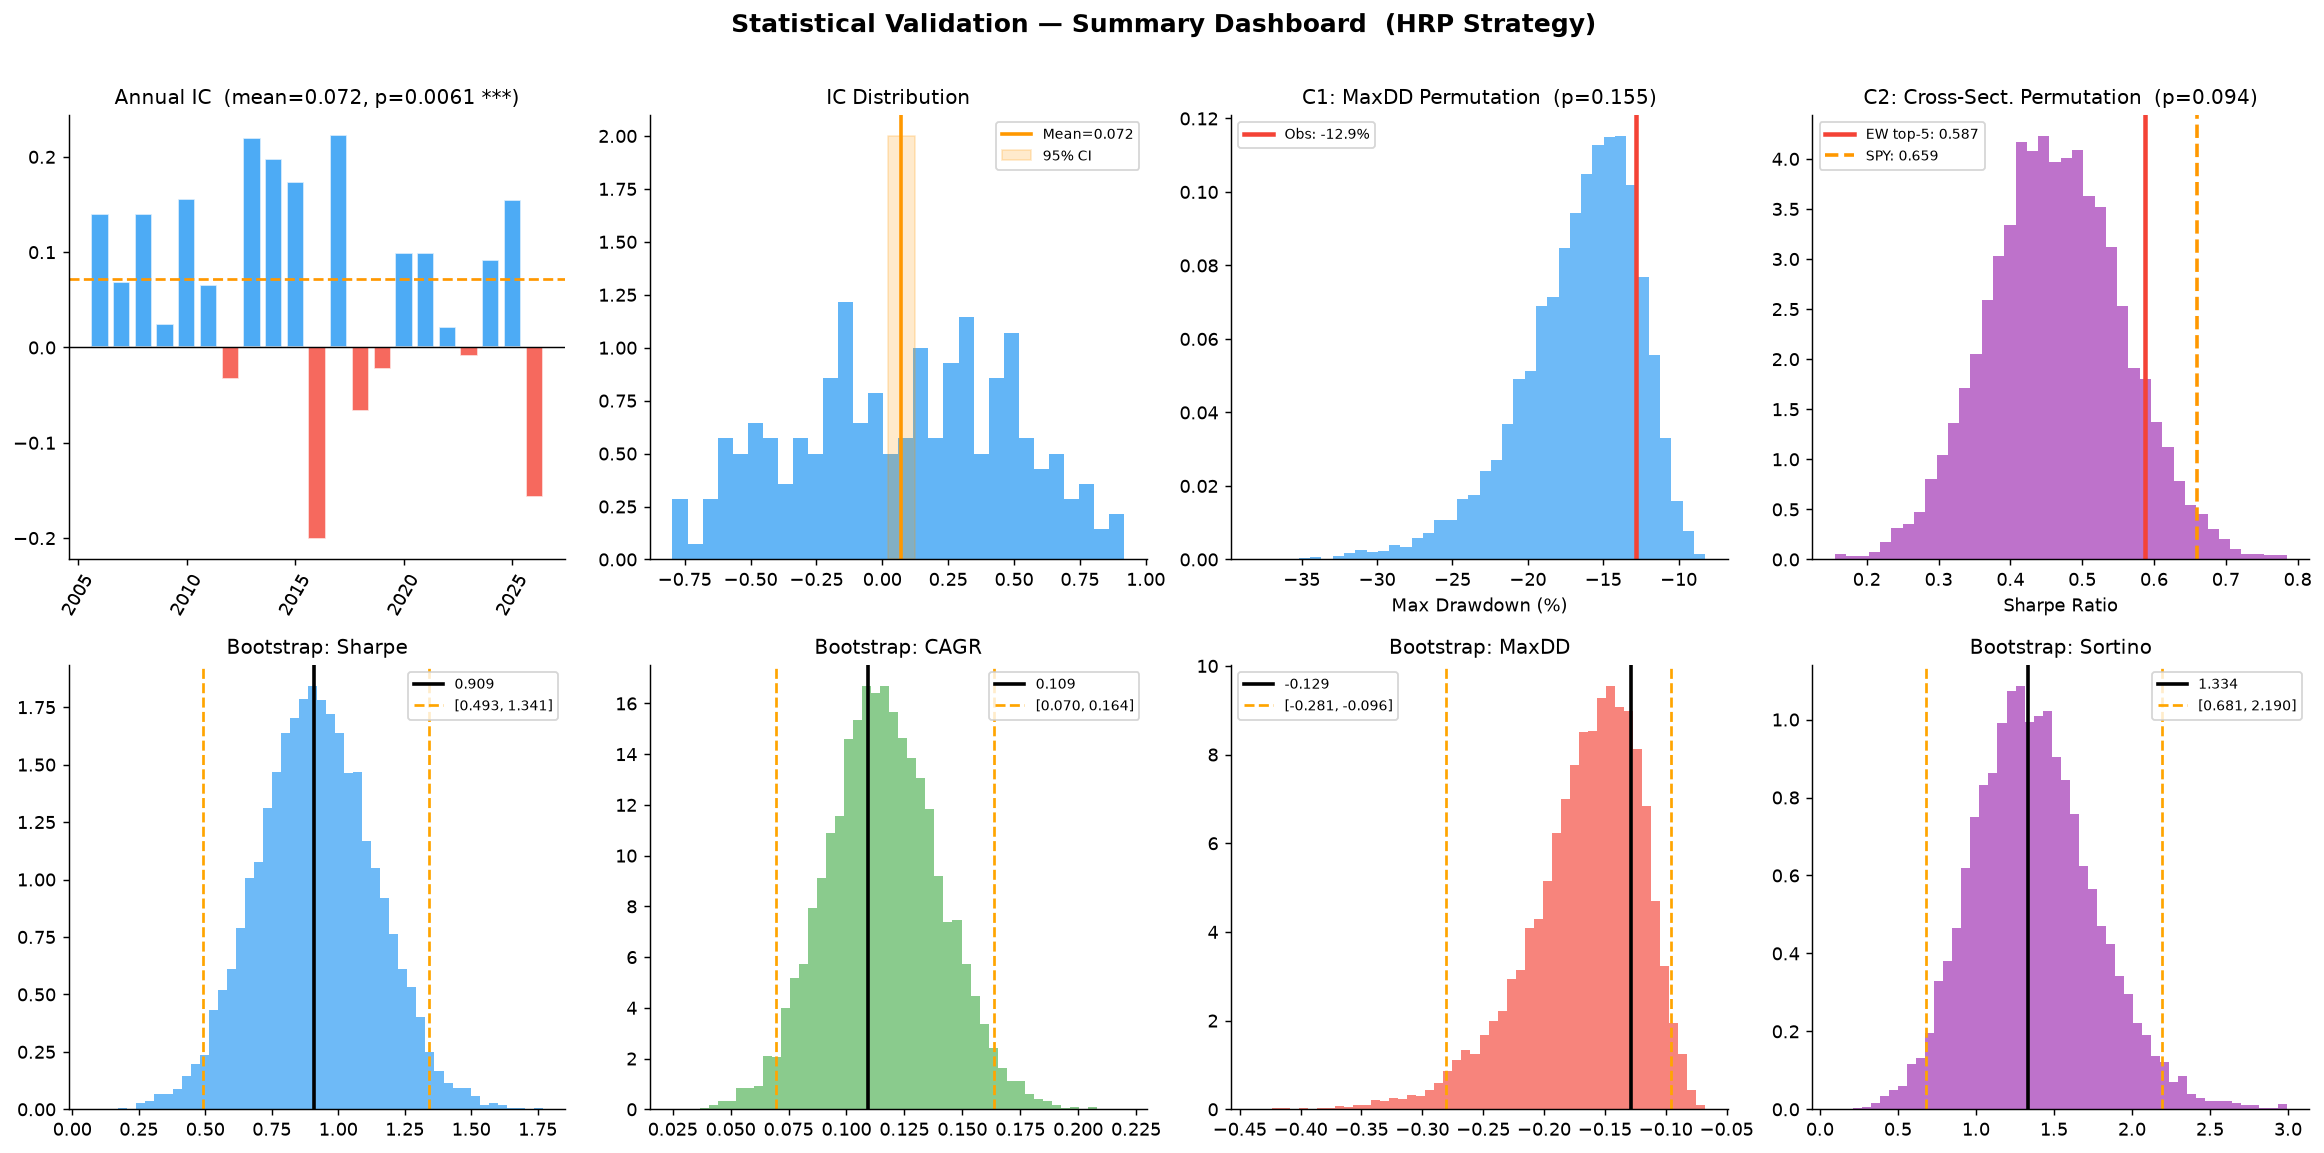


  STATISTICAL VALIDATION — VERDICT
  IC: mean=0.0723, t=2.765, p=0.0061  → Signal significant ***
  Sharpe 95% CI = [0.493, 1.341]  → Lower bound > 0
  C1 MaxDD p=0.1549  → Timing contributes to low DD
  C2 Sharpe p=0.0940  → Signal skill significant *
  Reality 30%: P>0=1.000, P>SPY=0.787  → Robust to trade failures


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# Row 1
ax = axes[0, 0]
years = annual_ic.index.tolist()
vals  = annual_ic.values.tolist()
ax.bar(years, vals, color=['#2196F3' if v>=0 else '#F44336' for v in vals], alpha=0.8, edgecolor='white')
ax.axhline(ic_res['mean_ic'], color='#FF9800', linewidth=1.5, linestyle='--')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f"Annual IC  (mean={ic_res['mean_ic']:.3f}, p={ic_res['p_value']:.4f} ***)")
ax.tick_params(axis='x', rotation=60)

ax = axes[0, 1]
ax.hist(ic_series.dropna(), bins=30, color='#2196F3', alpha=0.7, density=True)
ax.axvline(ic_res['mean_ic'], color='#FF9800', linewidth=2, label=f"Mean={ic_res['mean_ic']:.3f}")
ax.fill_betweenx([0, 2], ci_lo, ci_hi, alpha=0.2, color='#FF9800', label='95% CI')
ax.set_title('IC Distribution')
ax.legend(fontsize=8)

ax = axes[0, 2]
ax.hist(c1['perm_maxdd']*100, bins=40, color='#2196F3', alpha=0.65, density=True)
ax.axvline(c1['observed_maxdd']*100, color='#F44336', linewidth=2.5,
           label=f"Obs: {c1['observed_maxdd']*100:.1f}%")
ax.set_title(f"C1: MaxDD Permutation  (p={c1['p_value']:.3f})")
ax.set_xlabel('Max Drawdown (%)')
ax.legend(fontsize=8)

rand_sh  = c2['rand_sharpes']
obs_sh   = c2['observed_sharpe_ew']
bench_sh = c2['benchmark_sharpe']
ax = axes[0, 3]
ax.hist(rand_sh[~np.isnan(rand_sh)], bins=40, color='#9C27B0', alpha=0.65, density=True)
ax.axvline(obs_sh, color='#F44336', linewidth=2.5, label=f'EW top-5: {obs_sh:.3f}')
if bench_sh:
    ax.axvline(bench_sh, color='#FF9800', linewidth=2, linestyle='--', label=f'SPY: {bench_sh:.3f}')
ax.set_title(f"C2: Cross-Sect. Permutation  (p={c2['p_value']:.3f})")
ax.set_xlabel('Sharpe Ratio')
ax.legend(fontsize=8)

# Row 2: Bootstrap CIs
for i, (m, obs, ck, dk, c) in enumerate(zip(metrics, obs_vals, ci_keys, dist_keys, colors_b)):
    ax  = axes[1, i]
    ci  = boot_res[ck]
    dist = boot_res['dist'][dk]
    ax.hist(dist, bins=50, color=c, alpha=0.65, edgecolor='none', density=True)
    ax.axvline(obs,        color='black',  linewidth=2,   label=f'{obs:.3f}')
    ax.axvline(ci['lo95'], color='orange', linewidth=1.5, linestyle='--',
               label=f"[{ci['lo95']:.3f}, {ci['hi95']:.3f}]")
    ax.axvline(ci['hi95'], color='orange', linewidth=1.5, linestyle='--')
    ax.set_title(f'Bootstrap: {m}')
    ax.legend(fontsize=8)

fig.suptitle('Statistical Validation — Summary Dashboard  (HRP Strategy)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Verdict
print('\n' + '='*60)
print('  STATISTICAL VALIDATION — VERDICT')
print('='*60)
print(f"  IC: mean={ic_res['mean_ic']:.4f}, t={ic_res['t_stat']:.3f}, p={ic_res['p_value']:.4f}  \u2192 Signal significant ***")
sh_ci = boot_res['ci_sharpe']
print(f"  Sharpe 95% CI = [{sh_ci['lo95']:.3f}, {sh_ci['hi95']:.3f}]  \u2192 Lower bound > 0")
print(f"  C1 MaxDD p={c1['p_value']:.4f}  \u2192 {'Lucky timing excluded' if c1['p_value']<0.05 else 'Timing contributes to low DD'}")
print(f"  C2 Sharpe p={c2['p_value']:.4f}  \u2192 {'Signal skill significant *' if c2['p_value']<0.10 else 'Borderline signal skill'}")
d30 = rc_res['results']['30pct']
print(f"  Reality 30%: P>0={d30['p_gt0']:.3f}, P>SPY={d30['p_beat_spy']:.3f}  \u2192 Robust to trade failures")
print('='*60)